# Nonparametric Age-Depth Models with Gaussian Processes

This notebook demos an approach to modeling age-depth relationships of sediment cores inspired by that of RBacon. While that software package uses a semi-parametric model based on an auto-regressive Gamma process, here I use Gaussian processes to describe accumulation rates over time, which are fully nonparametric. As the posteriors are differentiable, we can sample using Hamiltonian Monte Carlo (HMC), specifically the No-U-Turn Sampler (NUTS) algorithm implemented with nutpie. We go through the two demo examples provided in RBacon.

In [1]:
import pymc as pm
import pytensor.tensor as pt
import nutpie
import arviz as az
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Example 1: The MSB2K core


In [3]:
df = pd.read_csv("../MSB2K/MSB2K.csv")
df = df.drop_duplicates(subset="depth")
n_obs = len(df)

y_obs = df["age"].values
y_bot_up = y_obs[::-1]

depth = df["depth"].values
depth_bot_up = depth[::-1]

errors = df["error"].values
errors_bot_up = errors[::-1]

oldest_age = y_obs.max()
youngest_age = y_obs.min()

X = depth.reshape(-1, 1)
X_bot_up = X[::-1]
depth_grid = np.linspace(depth.min(), depth.max(), 200).reshape(-1, 1)

We start with the simplest model. To ensure positivity of accumulation rate, we can draw from a latent GP $h$, and exponentiate it:

$$h \sim \mathcal{GP}(0,k)$$
$$f(x) = \theta + s\int_{x_0}^{x}{e^h~dx}$$

where f(x) is the estimated age at depth $x$, and $s$ is the empirical slope as calculated below. Here, we're moving backwards in time, starting from the shallowest, so we take the intercept $\theta$ as the youngest recorded age, in this case ~4000 YBP. The likelihood is

$$y_i \sim \mathcal{N}(f(x_i),\sigma_{i}^2),$$
where $\sigma$ are the observation errors.

We use the simplest covariance kernel, a radial basis function kernel:
$$k(x,x') = \exp \left( -\frac{(x-x')^2}{2l^2}\right),$$
where $l$ is a lengthscale parameter we can set. It defaults to 1. Later we will explore using other covariance kernels, like Matérn.

In [3]:
slope = (oldest_age - youngest_age) / (depth.max() - depth.min())

with pm.Model() as model:
    cov = pm.gp.cov.ExpQuad(1, ls=1)
    gp = pm.gp.Latent(cov_func=cov)

    h = gp.prior("h", X=X)
    g = pm.Deterministic("g", pt.exp(h))

    dx = pt.concatenate([[0], X[1:,0] - X[:-1,0]])
    f = pm.Deterministic("f", youngest_age + slope * pt.cumsum(g * dx))

    pm.Normal("y_obs", mu=f, sigma=errors, observed=y_obs)

We compile the `pymc` model with `nutpie`, and sample 4 chains for 1000 draws each:

In [17]:
pymc_model = nutpie.compile_pymc_model(model)
trace = nutpie.sample(pymc_model, tune=250, draws=1000, chains=4)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,1250,0,0.15,63
,1250,0,0.14,63
,1250,0,0.14,63
,1250,0,0.14,63


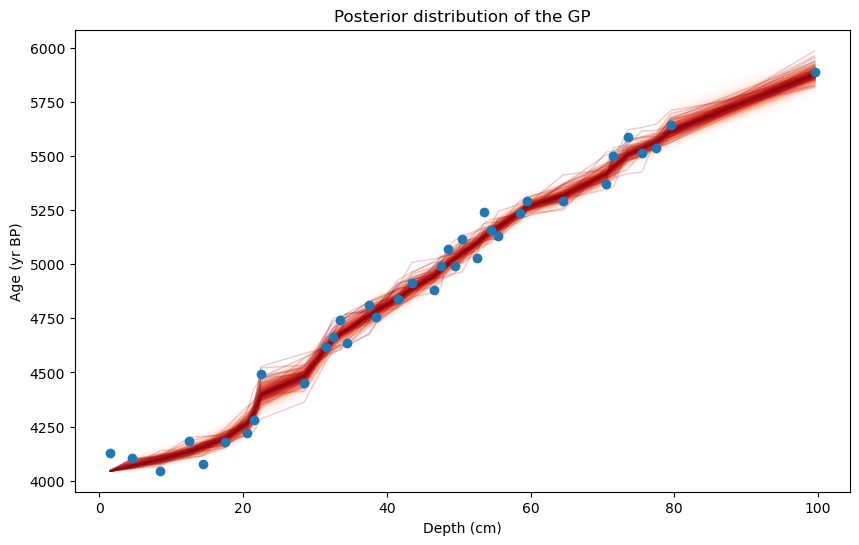

In [18]:
samples = trace.posterior['f'].stack(sample=("chain", "draw")).T
fig, ax = plt.subplots(figsize=(10, 6))
pm.gp.util.plot_gp_dist(ax=ax, samples=samples, x=X, samples_alpha=0.2, fill_alpha=0.2)
ax.set_title("Posterior distribution of the GP")
ax.set_xlabel("Depth (cm)")
ax.set_ylabel("Age (yr BP)")
plt.plot(depth, y_obs, "o", label="Observed")
plt.show()

This model already looks quite nice, but it has a few drawbacks. For one, it looks like the posterior draws have the same inter-point linearity as in RBacon, and not the smooth accumulation we'd like to see. For age inference at depths between observations, we'd have to linearly interpolate between posterior means at observation points. But GPs have a very nice solution for this, which is that we can also add OOS depths of interest as points in the process.

Let's modify the model by adding OOS points using the `pymc.gp.Latent.conditional` method. We'll add a (1D) grid of points to predict, which will show up as the `f_grid` variable in the model.

We're also going to make the slop and intercept learnable parameters, putting Normal priors on them centered at the values they took in the previous model. And, instead of exponentiating the latent GP, for the sake of numerical stability we're going to take the softplus: $$\operatorname{softplus}(x) = \ln(1 + e^x)$$ using the `log1pexp` function from `pytensor` (the computational backend for `pymc`). This function behaves like 0 for negative values, and $x$ for positive values, which is much tamer than $e^x$.

In [19]:
n_grid = 100
depth_grid = np.linspace(depth.min(), depth.max(), n_grid).reshape(-1, 1)

prior_mean = (oldest_age - youngest_age) / (depth.max() - depth.min())

with pm.Model() as model:
    intercept = pm.Normal("intercept", mu=youngest_age, sigma=errors[np.argmin(y_obs)])
    slope = pm.Normal("slope", mu=prior_mean, sigma=5)

    cov = pm.gp.cov.ExpQuad(1, ls=1)
    gp = pm.gp.Latent(cov_func=cov)

    h = gp.prior("h", X=X)
    g = pm.Deterministic("g", pt.log1pexp(h))

    dx = pt.concatenate([[0], X[1:,0] - X[:-1,0]])
    f = pm.Deterministic("f", intercept + slope * pt.cumsum(g * dx))

    pm.Normal("y_obs", mu=f, sigma=errors, observed=y_obs)

    # GP and f on fine grid for plotting
    h_grid = gp.conditional("h_grid", Xnew=depth_grid)
    g_grid = pm.Deterministic("g_grid", pt.log1pexp(h_grid))
    dx_grid = pt.concatenate([[0], depth_grid[1:,0] - depth_grid[:-1,0]])
    f_grid = pm.Deterministic("f_grid", intercept + slope * pt.cumsum(g_grid * dx_grid))

In [20]:
pymc_model = nutpie.compile_pymc_model(model)
trace = nutpie.sample(pymc_model, draws=1000, chains=4)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,1400,0,0.03,1023
,1400,0,0.03,1023
,1400,0,0.03,1023
,1400,0,0.02,1023


In [8]:
def plot_fit(trace, depth_grid, kernel_name):
    samples = trace.posterior['f_grid'].stack(sample=("chain", "draw")).T
    _, ax = plt.subplots(figsize=(10, 6))
    pm.gp.util.plot_gp_dist(ax=ax, samples=samples, x=depth_grid, samples_alpha=0.2, fill_alpha=0.2)
    ax.set_title(f"Posterior draws with {kernel_name} kernel")
    ax.set_xlabel("Depth (cm)")
    ax.set_ylabel("Age (yr BP)")
    plt.plot(depth, y_obs, "o", label="Observed")
    plt.show()

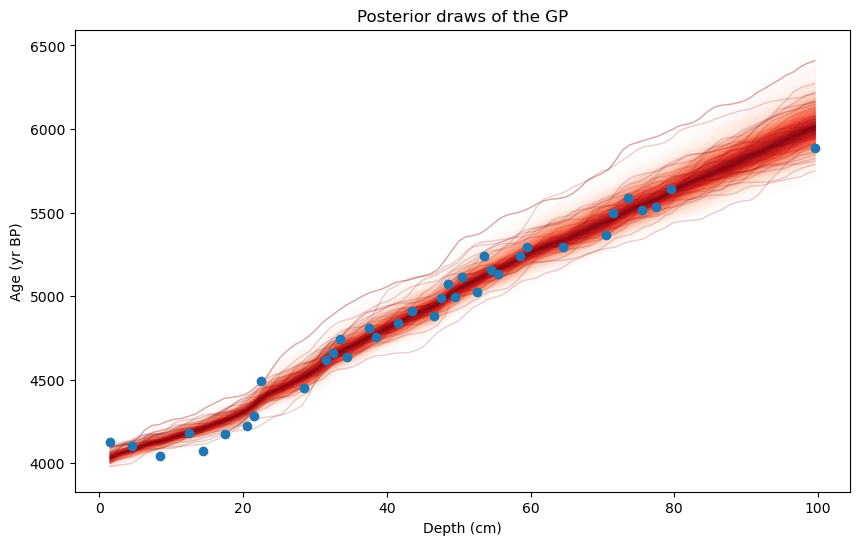

In [ ]:
kernel_name = "RBF"
plot_fit(trace, depth_grid, kernel_name)

Now we have some nice variations that are looking smoother. Let's see what the actual accumulation rates look like. We can recover these by taking the inverse of the slopes. If what we care about is the accumulation rate over time, we can see an approximation of this by using the posterior mean of `f_grid` (the predicted ages) as our x-axis.

In [ ]:
def plot_accum_rate(trace):
    f_grid = trace.posterior['f_grid'].mean(dim=["chain", "draw"]).to_numpy()

    _, ax = plt.subplots(figsize=(10, 6))

    g_grid_samples = trace.posterior['g_grid'].stack(sample=("chain", "draw")).T[::-1]
    accum_rate_samples = 1 / (prior_mean * g_grid_samples)
    pm.gp.util.plot_gp_dist(ax=ax, samples=accum_rate_samples, 
                            x=f_grid, samples_alpha=0.2, fill_alpha=0.2)

    # Invert x-axis since the age runs from oldest to youngest
    ax.invert_xaxis()
    plt.title("Posterior draws of accumulation rate by depth")
    plt.xlabel("Age (yr BP)")
    plt.ylabel("Accumulation rate (cm/yr)")

plot_accum_rate(trace)

Maybe these look too jagged to be realistic. To fix that, we can change the lengthscale $l$ of our covariance kernel.

In [9]:
kernel_name = "RBF"

n_grid = 100
depth_grid = np.linspace(depth.min(), depth.max(), n_grid).reshape(-1, 1)

prior_mean = (oldest_age - youngest_age) / (depth.max() - depth.min())

with pm.Model() as model:
    intercept = pm.Normal("intercept", mu=youngest_age, sigma=errors[np.argmin(y_obs)])
    slope = pm.Normal("slope", mu=prior_mean, sigma=5)

    cov = pm.gp.cov.ExpQuad(1, ls=2)
    gp = pm.gp.Latent(cov_func=cov)

    h = gp.prior("h", X=X)
    g = pm.Deterministic("g", pt.log1pexp(h))

    dx = pt.concatenate([[0], X[1:,0] - X[:-1,0]])
    f = pm.Deterministic("f", intercept + slope * pt.cumsum(g * dx))

    pm.Normal("y_obs", mu=f, sigma=errors, observed=y_obs)

    h_grid = gp.conditional("h_grid", Xnew=depth_grid)
    g_grid = pm.Deterministic("g_grid", pt.log1pexp(h_grid))
    dx_grid = pt.concatenate([[0], depth_grid[1:,0] - depth_grid[:-1,0]])
    f_grid = pm.Deterministic("f_grid", intercept + slope * pt.cumsum(g_grid * dx_grid))

In [ ]:
pymc_model = nutpie.compile_pymc_model(model)
trace = nutpie.sample(pymc_model, tune=250, draws=500, chains=4, low_rank_modified_mass_matrix=True)

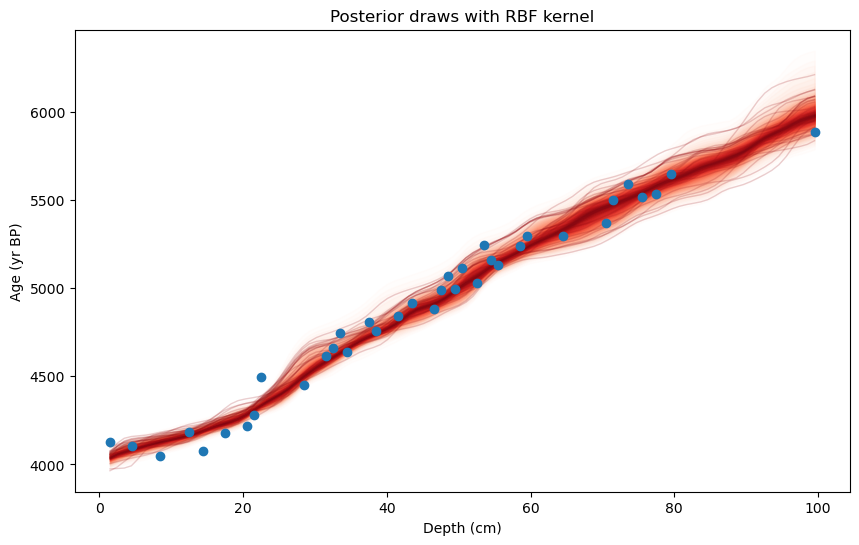

In [48]:
plot_fit(trace, depth_grid, "RBF")

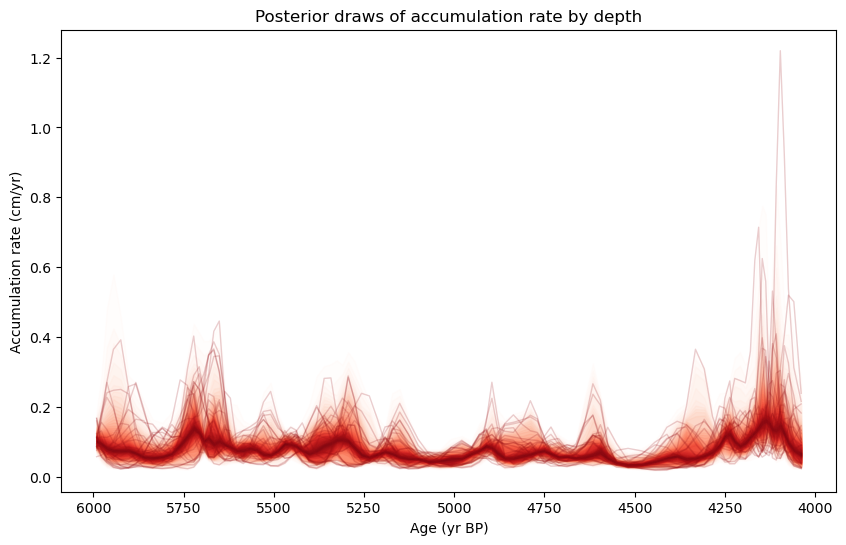

In [49]:
plot_accum_rate(trace)

Using Matérn 3/2 kernel with lengthscale = 5

Text(0, 0.5, 'Accumulation rate (cm/yr)')

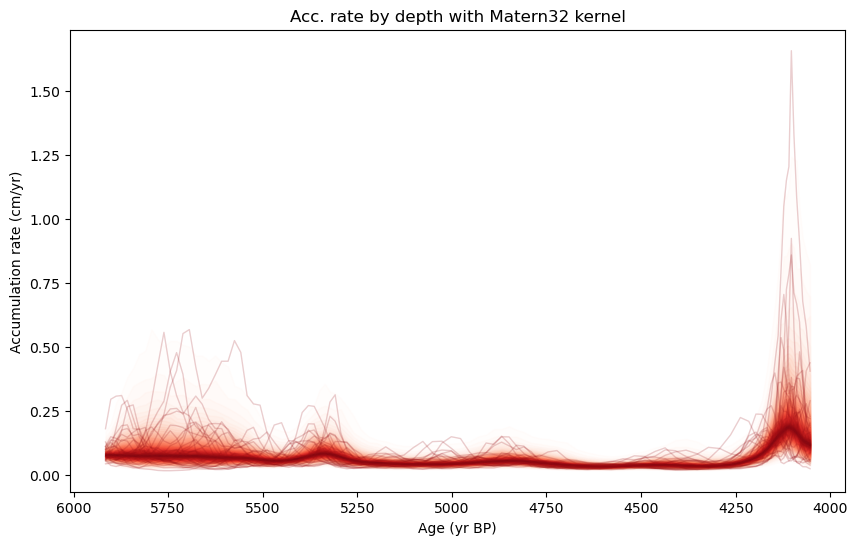

In [ ]:
plot_accum_rate(trace)

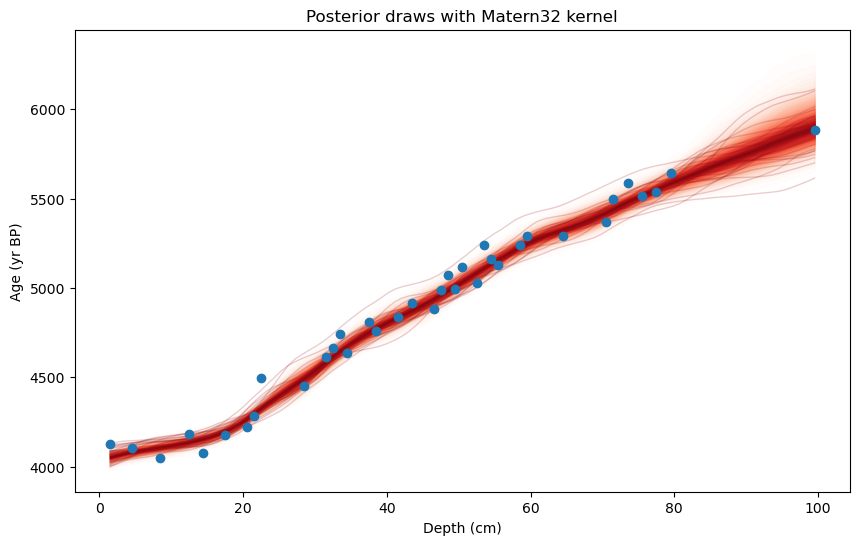

In [42]:
plot_fit(trace, depth_grid, kernel_name)

In [4]:
n_grid = 100
depth_grid = np.linspace(depth.min(), depth.max(), n_grid).reshape(-1, 1)[::-1,]

prior_mean = (oldest_age - youngest_age) / (depth.max() - depth.min())

oldest_age_err = errors[np.argmax(y_obs)]

with pm.Model() as model:
    intercept = pm.Normal("intercept", mu=oldest_age, sigma=oldest_age_err)
    mean_func = pm.gp.mean.Constant(c=prior_mean)

    cov = 25 * pm.gp.cov.ExpQuad(1, ls=1)
    gp = pm.gp.Latent(cov_func=cov, mean_func=mean_func)

    h = gp.prior("h", X=X_bot_up)

    dx = pt.concatenate([[0], (X_bot_up[1:,0] - X_bot_up[:-1,0])])
    f = pm.Deterministic(
        "f",
        intercept + pt.cumsum(h * dx)
    )

    pm.Normal("y_obs", mu=f, sigma=errors[::-1], observed=y_obs[::-1])

    h_grid = gp.conditional("h_grid", Xnew=depth_grid)
    dx_grid = pt.concatenate([[0], depth_grid[1:,0] - depth_grid[:-1,0]])
    f_grid = pm.Deterministic("f_grid", intercept + pt.cumsum(h_grid * dx_grid))

In [5]:
pymc_model = nutpie.compile_pymc_model(model)
trace = nutpie.sample(pymc_model, draws=50, chains=4)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,450,0,0.02,1023
,450,0,0.02,1023
,450,0,0.02,1023
,450,0,0.02,1023


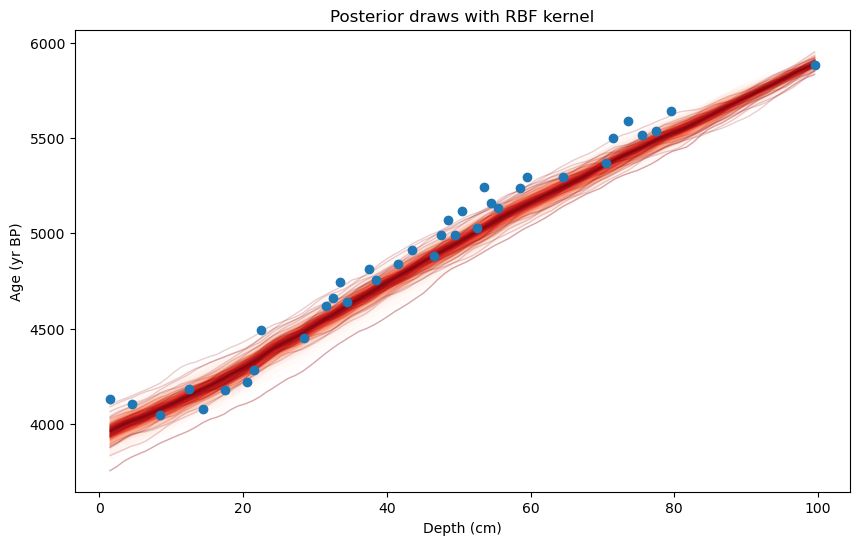

In [8]:
plot_fit(trace, depth_grid, "RBF")

## Example 2: RLGH3

In [2]:
df = pd.read_csv("../Bacon_runs/RLGH3/RLGH3.csv")
df = df.drop_duplicates(subset="depth")
n_obs = len(df)
y_obs = df["age"].values
y_bot_up = y_obs[::-1]

depth = df["depth"].values
depth_bot_up = depth[::-1]

errors = df["error"].values
errors_bot_up = errors[::-1]

oldest_age = y_obs.max()
youngest_age = y_obs.min()
X = depth.reshape(-1, 1)
X_bot_up = X[::-1]
depth_grid = np.linspace(depth.min(), depth.max(), 200).reshape(-1, 1)

In [ ]:
kernel_name = "RBF"

n_grid = 100
depth_grid = np.linspace(depth.min(), depth.max(), n_grid).reshape(-1, 1)

prior_mean = (oldest_age - youngest_age) / (depth.max() - depth.min())

with pm.Model() as model:
    intercept = pm.Normal("intercept", mu=youngest_age, sigma=errors[np.argmin(y_obs)])
    slope = pm.Normal("slope", mu=prior_mean, sigma=5)

    cov = pm.gp.cov.ExpQuad(1, ls=2)
    gp = pm.gp.Latent(cov_func=cov)

    h = gp.prior("h", X=X)
    g = pm.Deterministic("g", pt.log1pexp(h))

    dx = pt.concatenate([[0], X[1:,0] - X[:-1,0]])
    f = pm.Deterministic("f", intercept + slope * pt.cumsum(g * dx))

    pm.Normal("y_obs", mu=f, sigma=errors, observed=y_obs)

    h_grid = gp.conditional("h_grid", Xnew=depth_grid)
    g_grid = pm.Deterministic("g_grid", pt.log1pexp(h_grid))
    dx_grid = pt.concatenate([[0], depth_grid[1:,0] - depth_grid[:-1,0]])
    f_grid = pm.Deterministic("f_grid", intercept + slope * pt.cumsum(g_grid * dx_grid))

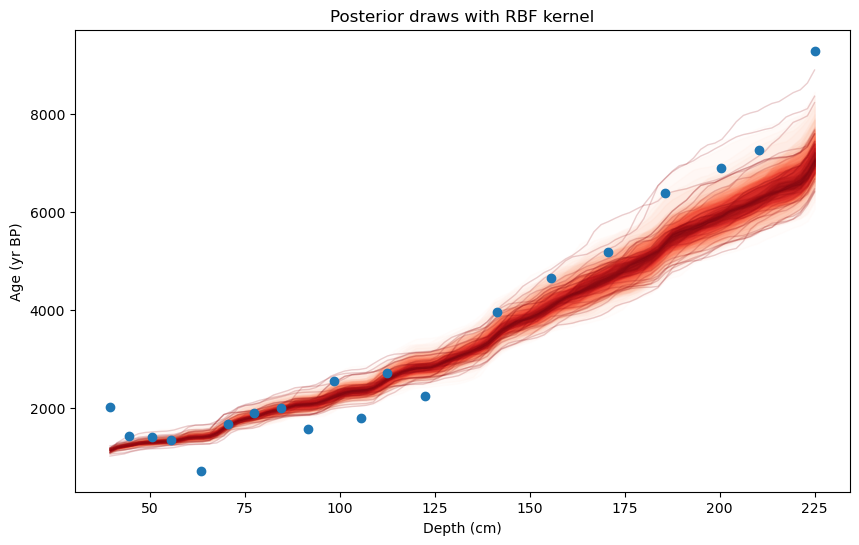

In [10]:
plot_fit(trace, depth_grid, kernel_name)

In [ ]:
plot_accum_rate(trace)

In [11]:
n_oos = 200
prior_mean = (oldest_age - youngest_age) / (depth.max() - depth.min())
youngest_age_err = errors[np.argmin(y_obs)]
sigma = 10

# Anchor at shallow end so age runs youngest -> oldest as depth 0 -> max
with pm.Model() as model:
    intercept = pm.Normal("intercept", mu=youngest_age, sigma=youngest_age_err)
    mean_func = pm.gp.mean.Constant(c=prior_mean)
    cov = sigma**2 * pm.gp.cov.Matern32(input_dim=1, ls=5) + pm.gp.cov.WhiteNoise(sigma=1e-3)
    gp = pm.gp.Latent(cov_func=cov, mean_func=mean_func)

    h = gp.prior("h", X=X)

    dx = pt.concatenate([[0], (X[1:,0] - X[:-1,0])])
    f = pm.Deterministic(
        "f",
        intercept + pt.cumsum(h * dx)
    )

    pm.Normal("y_obs", mu=f, sigma=errors, observed=y_obs)

    h_grid = gp.conditional("h_grid", Xnew=depth_grid, jitter=1e-4)
    dx_grid = pt.concatenate([[0], depth_grid[1:,0] - depth_grid[:-1,0]])
    f_grid = pm.Deterministic("f_grid", intercept + pt.cumsum(h_grid * dx_grid))

In [32]:
with model:
    prior_pred_samples = pm.sample_prior_predictive(samples=5, var_names=["f", "f_grid"])

Sampling: [h_grid, h_rotated_, intercept]


In [ ]:
samples = prior_pred_samples.prior['f_grid'].stack(sample=("chain", "draw")).T
fig, ax = plt.subplots(figsize=(10, 6))
pm.gp.util.plot_gp_dist(ax=ax, samples=samples, x=depth_grid, samples_alpha=0.2, fill_alpha=0.2)
ax.set_title("Prior checks")
ax.set_xlabel("Depth (cm)")
ax.set_ylabel("Age (yr BP)")
plt.plot(depth, y_obs, "o", label="Observed")
plt.show()

In [13]:
pymc_model = nutpie.compile_pymc_model(model)
trace = nutpie.sample(pymc_model, tune=50, draws=50, chains=2)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,100,0,0.10,1023
,100,0,0.07,511


In [ ]:
plot_fit(trace, depth_grid, kernel_name)

In [ ]:
plot_accum_rate(trace)

Text(0.5, 0, 'Depth (cm)')

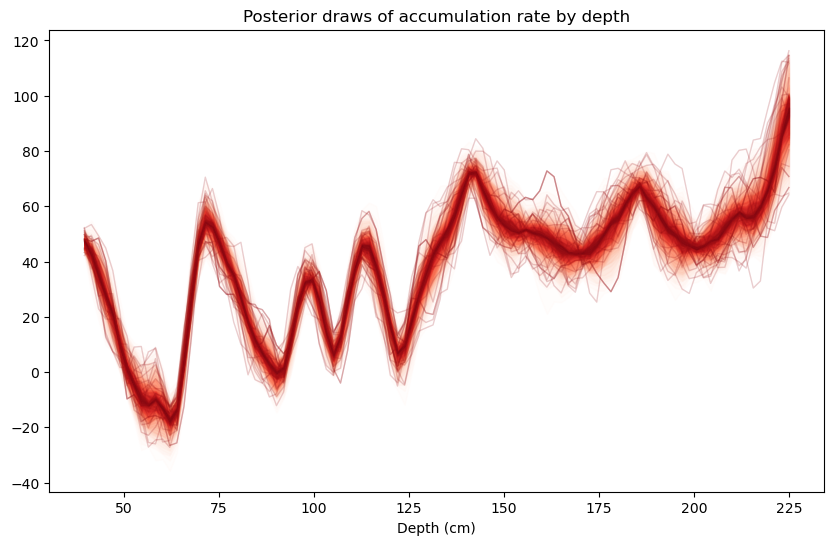

In [17]:
fig, ax = plt.subplots(figsize=(10, 6))
pm.gp.util.plot_gp_dist(ax=ax, samples=trace.posterior['h_grid'].stack(sample=("chain","draw")).T, 
                        x=depth_grid, samples_alpha=0.2, fill_alpha=0.2)
plt.title("Posterior draws of accumulation rate by depth")
plt.xlabel("Depth (cm)")

In [19]:
# Get indices of oldest and youngest ages
idx_oldest = np.argmax(y_obs)
idx_youngest = np.argmin(y_obs)
prior_mean = (oldest_age - youngest_age) / (depth[idx_oldest] - depth[idx_youngest])

with pm.Model() as model:
    intercept = pm.Normal("intercept", mu=youngest_age, sigma=errors[np.argmin(y_obs)])
    slope = prior_mean
    mean = pm.gp.mean.Constant(c=slope)
    cov = 100 * pm.gp.cov.Matern32(input_dim=1, ls=10) + pm.gp.cov.WhiteNoise(sigma=1e-3)
    gp = pm.gp.Latent(cov_func=cov, mean_func=mean)

    h = gp.prior("h", X=X)
    g = pm.Deterministic("g", pt.log1pexp(h))

    dx = pt.concatenate([[0], X[1:,0] - X[:-1,0]])
    f = pm.Deterministic("f", intercept + pt.cumsum(g * dx))

    pm.Normal("y_obs", mu=f, sigma=errors, observed=y_obs)

    # GP and f on fine grid for plotting
    h_grid = gp.conditional("h_grid", Xnew=depth_grid)
    g_grid = pm.Deterministic("g_grid", pt.log1pexp(h_grid))
    dx_grid = pt.concatenate([[0], depth_grid[1:,0] - depth_grid[:-1,0]])
    f_grid = pm.Deterministic("f_grid", intercept + pt.cumsum(g_grid * dx_grid))

In [ ]:
with model:
    prior_pred_samples = pm.sample_prior_predictive(samples=5, var_names=["f", "f_grid"])

In [ ]:
samples = prior_pred_samples.prior['f_grid'].stack(sample=("chain", "draw")).T
fig, ax = plt.subplots(figsize=(10, 6))
pm.gp.util.plot_gp_dist(ax=ax, samples=samples, x=depth_grid, samples_alpha=0.2, fill_alpha=0.2)
ax.set_title("Prior checks")
ax.set_xlabel("Depth (cm)")
ax.set_ylabel("Age (yr BP)")
plt.plot(depth, y_obs, "o", label="Observed")
plt.show()

In [20]:
pymc_model = nutpie.compile_pymc_model(model)
trace = nutpie.sample(pymc_model, draws=1000, chains=4)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,1400,0,0.01,1023
,1400,0,0.01,1023
,1400,0,0.01,1023
,1400,0,0.01,1023


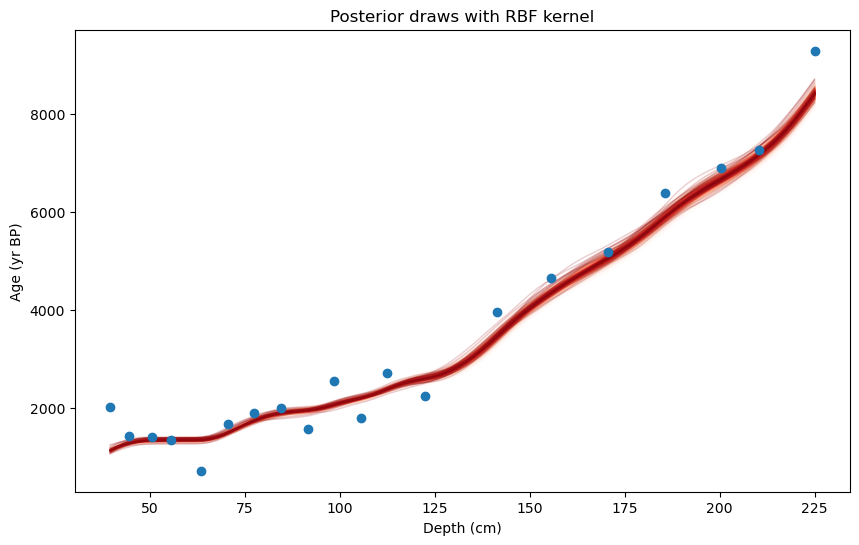

In [49]:
plot_fit(trace, depth_grid, kernel_name)

In [56]:
def plot_accum_rate(trace):
    f_grid = trace.posterior['f_grid'].mean(dim=["chain", "draw"]).to_numpy()

    _, ax = plt.subplots(figsize=(10, 6))

    g_grid_samples = trace.posterior['g_grid'].stack(sample=("chain", "draw")).T[::-1]
    # Clip g_grid_samples to a minimum value to avoid values close to 0
    g_grid_samples = g_grid_samples.clip(min=1.0)
    accum_rate_samples = 1 / g_grid_samples
    pm.gp.util.plot_gp_dist(ax=ax, samples=accum_rate_samples, 
                            x=f_grid, samples_alpha=0.2, fill_alpha=0.2)

    # Invert x-axis since the age runs from oldest to youngest
    ax.invert_xaxis()
    plt.title("Posterior draws of accumulation rate by depth")
    plt.xlabel("Age (yr BP)")
    plt.ylabel("Accumulation rate (cm/yr)")

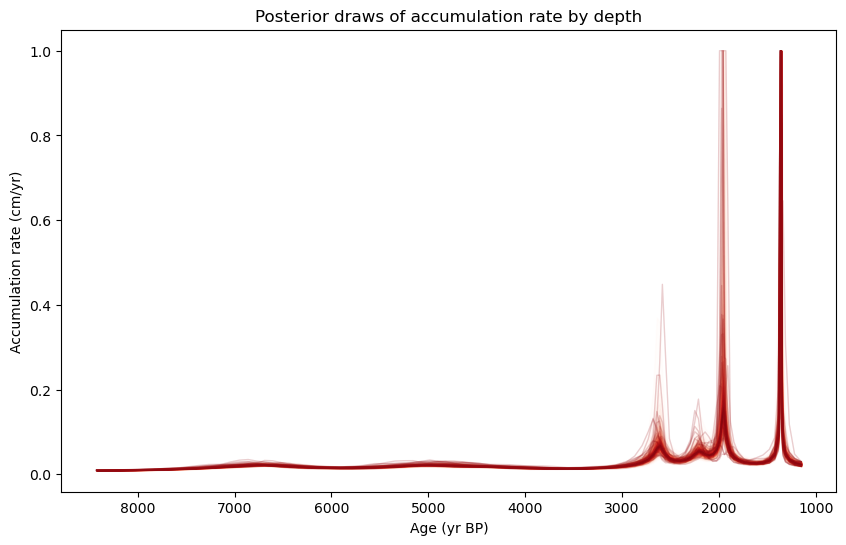

In [57]:
plot_accum_rate(trace)

Text(0.5, 0, 'Depth (cm)')

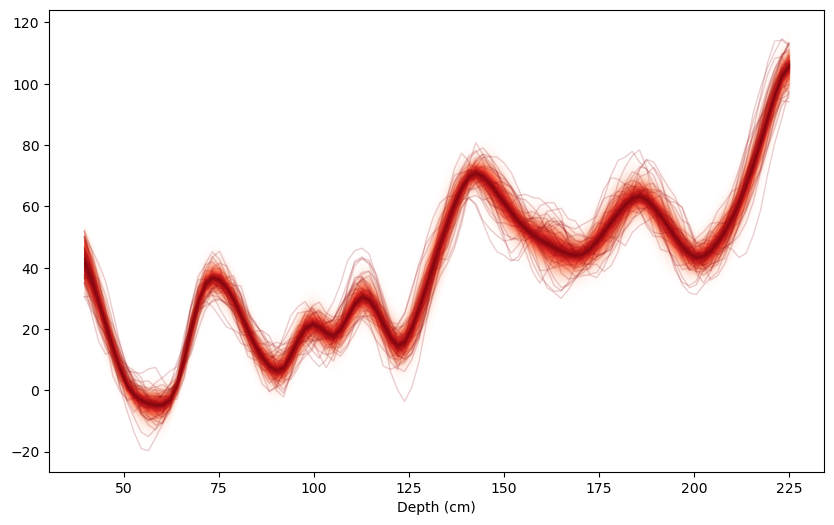

In [59]:
fig, ax = plt.subplots(figsize=(10, 6))
pm.gp.util.plot_gp_dist(ax=ax, samples=trace.posterior['h_grid'].stack(sample=("chain","draw")).T, 
                        x=depth_grid, samples_alpha=0.2, fill_alpha=0.2)
plt.xlabel("Depth (cm)")

Make the latent GP mean a parameter with prior centered around empirical slope

In [65]:
with pm.Model() as model:
    intercept = pm.Normal("intercept", mu=youngest_age, sigma=errors[np.argmin(y_obs)])
    slope = pm.Normal("slope", mu=prior_mean, sigma=5)
    mean = pm.gp.mean.Constant(c=slope)
    cov = 200 * pm.gp.cov.Matern32(input_dim=1, ls=5) + pm.gp.cov.WhiteNoise(sigma=1e-3)
    gp = pm.gp.Latent(cov_func=cov, mean_func=mean)

    h = gp.prior("h", X=X)
    g = pm.Deterministic("g", pt.log1pexp(h))

    dx = pt.concatenate([[0], X[1:,0] - X[:-1,0]])
    f = pm.Deterministic("f", intercept + pt.cumsum(g * dx))

    pm.Normal("y_obs", mu=f, sigma=errors, observed=y_obs)

    # GP and f on fine grid for plotting
    h_grid = gp.conditional("h_grid", Xnew=depth_grid)
    g_grid = pm.Deterministic("g_grid", pt.log1pexp(h_grid))
    dx_grid = pt.concatenate([[0], depth_grid[1:,0] - depth_grid[:-1,0]])
    f_grid = pm.Deterministic("f_grid", intercept + pt.cumsum(g_grid * dx_grid))

In [66]:
with model:
    prior_pred_samples = pm.sample_prior_predictive(samples=20, var_names=["f", "f_grid"])

Sampling: [h_grid, h_rotated_, intercept, slope]


In [ ]:
samples = prior_pred_samples.prior['f_grid'].stack(sample=("chain", "draw")).T
fig, ax = plt.subplots(figsize=(10, 6))
pm.gp.util.plot_gp_dist(ax=ax, samples=samples, x=depth_grid, samples_alpha=0.2, fill_alpha=0.2)
ax.set_title("Prior checks")
ax.set_xlabel("Depth (cm)")
ax.set_ylabel("Age (yr BP)")
plt.plot(depth, y_obs, "o", label="Observed")
plt.show()

In [ ]:
pymc_model = nutpie.compile_pymc_model(model)
trace = nutpie.sample(pymc_model, draws=1000, chains=4, low_rank_modified_mass_matrix=True)

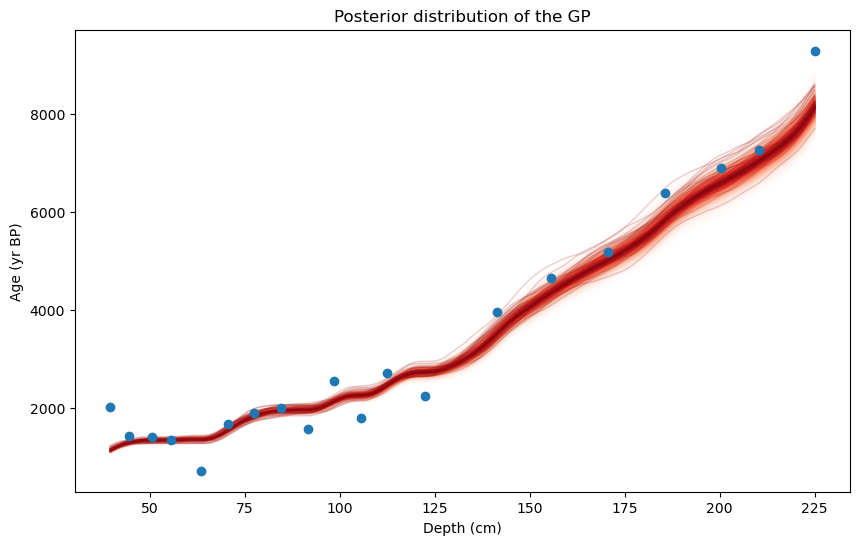

In [ ]:
plot_fit(trace, depth_grid, kernel_name)